# Module 12 Assignment: Generative AI with Diffusion Models
This assignment explores what we have learned in Module 12, and in particular, we will learn more about diffusion models, CLIP text embeddings, and prompt-based image generation using Stable Diffusion.

If you would like to run this code yourself, it is recommended to change your runtime type to GPU. Also, if you make your own changes, remember to save a copy of it in your Drive. If you forget to do so, your changes will be lost.

Let's first install the packages that we will need.

In [ ]:
# 🔧 Install Required Packages
!pip install -q diffusers transformers accelerate torch torchvision ftfy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.8 MB/s eta 0:00:00


## 🌀 Part 1: Text-to-Image Generation
We will first explore generating images from text prompts using a pretrained Stable Diffusion model.

We start with importing the packages that we will need:


- `torch` provides the core functionality for **PyTorch**, which is our deep learning framework
- `diffusers.StableDiffusionPipeline` helps load and use prtrained text-to-image diffusion models and automatiaclly handles the denoising process, CLIP text embeddings (discussed lateR), and iamge generation
- `PIL.Image` handles opening, saving, resizing, and manipulating images, as well as displaying or converting output images from models
- `matplotlib.pyplot` handles displaying generated images inline this notebook

In [ ]:
import torch
from diffusers import StableDiffusionPipeline
from PIL import Image
import matplotlib.pyplot as plt
import time

The below code generates an image of a hummingbird. Let's dive into the code block-by-block to enhance our udnerstanding. The first block loads the Stable Diffusion v1.5 model from the Hugging Face model hub (`runwayml/stable-diffusion-v1-5`). `model_id` identifies which model we use. Overall, this block sets up the pretrained image generation pipeline that takes a text prompt and generates a corresponding image.

The second block is the core image generation step, where the model uses diffusion-based denoising to create a visual interpretation of the prompt. Here, we feed the prompt into the pipeline to generate an image and then extract the first image from the output (some pipelines can return multiple images).

The final block uses matplotlib to display the generated image. `plt.imshow(image)` renders the image, `axis('off')` hides the axis ticks and labels, `title(...)` gives the plot a title, and `show()` displays the image output.

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

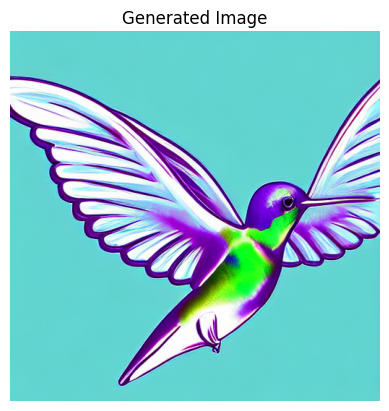

In [ ]:
model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
).to("cuda")

prompt = "A futuristic hummingbird in profile view, blue-green color, digital art"
image = pipe(prompt).images[0]

plt.imshow(image)
plt.axis('off')
plt.title("Generated Image")
plt.show()

Let's also explore briefly what other stable diffusion models we can use! In particular, go to the [Hugging Face hub](https://huggingface.co/) and search for the followign models:
- `Linaqruf/anime-detailer-xl-lora`
- `nitrosocke/mo-di-diffusion`
- `nitrosocke/Ghibli-Diffusion`
- `prompthero/openjourney-v4`

**Question 1** is about the code and outputs above.

## Part 2: CLIP Embeddings and Similarity
Let's now further explore CLIP embeddings and similarity between prompts.

Recall from the lectures in this module that CLIP (Contrastive Language–Image Pre-training) is a model developed by OpenAI that learns to connect images and text. It does this by training on a huge dataset of image–caption pairs and learning to embed (i.e. convert) both images and text into a shared vector space. Once embedded, both an image and a text prompt are represented as high-dimensional vectors.

Similarity between prompts is then measured by using cosine similarity of the prompts' respective vector embeddings — the closer the vectors, the more semantically aligned the image and the text are.

We start with importing the packages that we will need:


- `CLIPProcessor` is a preprocessing utility from Hugging Face’s transformers library. It handles all the steps required to prepare images and text for input into the CLIP model (like resizing, normalization, and tokenization). Since CLIP needs both image and text to be in specific formats CLIPProcessor makes it easy to convert raw data into model-ready tensors.

- `CLIPModel` is the pretrained CLIP model itself. It takes the processed inputs from CLIPProcessor and generates embeddings (i.e., feature vectors) for both images and text in a shared space. We use `CLIPModel` to get the image and text representations needed to compare them for similarity.

- `cosine_similarity` is a function from `PyTorch` that computes the cosine similarity between two sets of vectors — which tells us how close or aligned two embeddings are in the CLIP space. This is important since a high cosine similarity means the image and text match well (e.g., an image of a dog and the text “a dog”).

In [ ]:
from transformers import CLIPProcessor, CLIPModel
from torch.nn.functional import cosine_similarity

The code below extracts the CLIP embeddings for several input text prompts. Let's look more closely at the code, block-by-block.

The first block  loads the pretrained CLIP model and processor. In particular, `CLIPModel.from_pretrained(...)` loads the pretrained CLIP model weights from Hugging Face. This model can generate embeddings for both text and images in a shared space. `CLIPProcessor.from_pretrained(...)` loads the matching preprocessor that handles tokenization and formatting for text (and optionally image) inputs. Note that both the model and preprocessor must be paired and match the model variant (`clip-vit-base-patch32` here). The processor prepares inputs, and the model generates embeddings.

The next block of code creates a list of two descriptive text prompts, which we compare to each other using CLIP embeddings.

The next block of code first uses the `CLIPProcessor` to tokenize the text, add padding so both inputs have the same length, and return everything as `PyTorch` tensors (`return_tensors="pt"`). This is important because the model expects padded, tokenized tensor inputs — this line converts raw strings into that format. Then, we generate the embeddings with the CLIP model, where `get_text_features(...)` passes the tokenized text through the CLIP model to get text embeddings. Remember that these embeddings are how CLIP represents the meaning of each text prompt in high-dimensional space.

The final block of code computes and prints the cosine similarity between the two text inputs. Recall that the cosine similarity is a measure of how similar the two embeddings are, where 1.0 means perfectly aligned (same meaning) and 0.0 means orthogonal (unrelated). This gives us a numerical score for how related the two prompts are, according to CLIP’s learned understanding.



In [ ]:
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

texts = ["A brown angora cat sleeping on a couch",
         "A mountain with snow, blue ambiance"]

inputs = clip_processor(text=texts, return_tensors="pt", padding=True)
with torch.no_grad():
    embeddings = clip_model.get_text_features(**inputs)

cos_sim = cosine_similarity(embeddings[0], embeddings[1], dim=0).item()
print(f"Cosine similarity between the two text prompts: {cos_sim:.4f}")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Cosine similarity between the two text prompts: 0.3393


**Question 2** is about the code and prompts above.

## Part 3: Prompt Style Comparison

We will now explore a taste of prompt engineering, and in particular, how different descriptive styles influence the output image. Take a look at the code and outputs below and observe how the prompts affect the images. Note that the images are in the same order as the prompts.

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

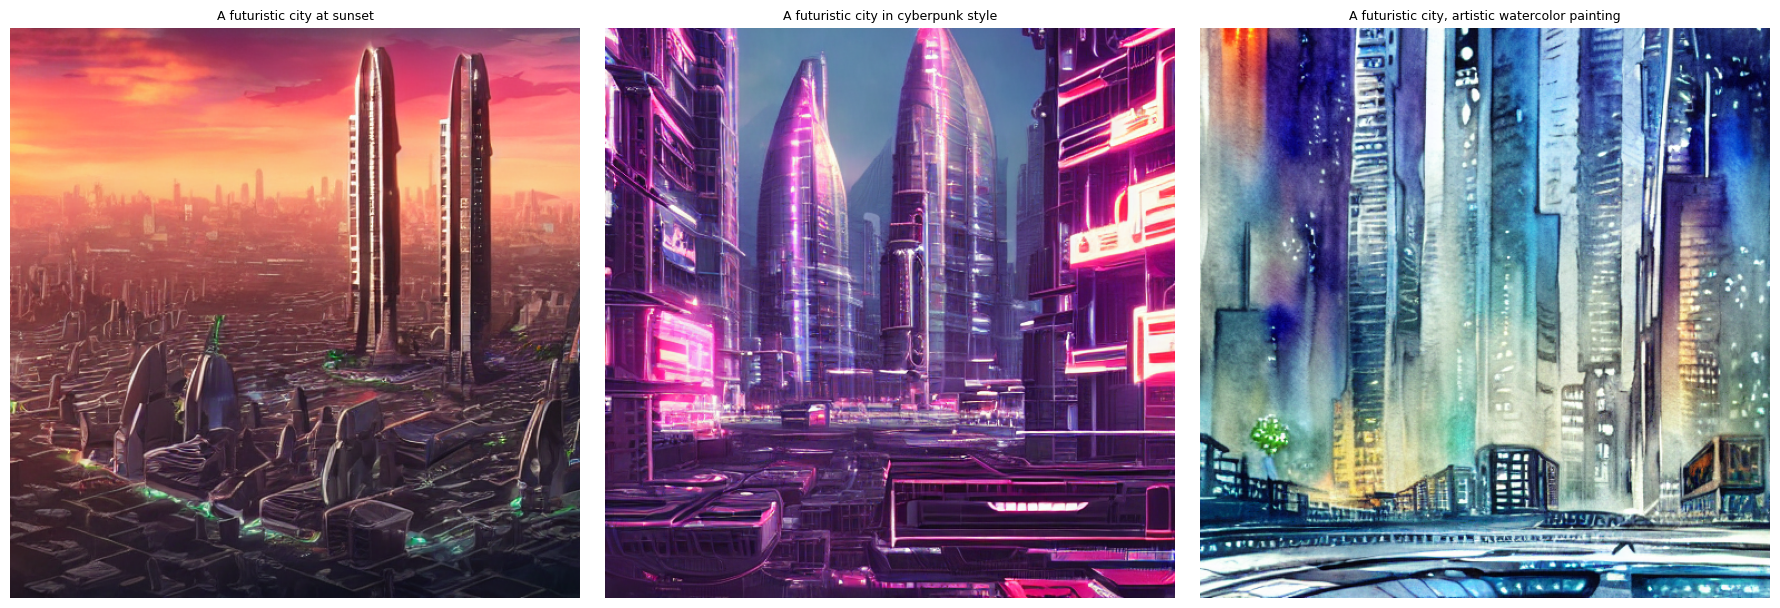

In [ ]:
prompts = [
    "A futuristic city at sunset",
    "A futuristic city in cyberpunk style",
    "A futuristic city, artistic watercolor painting"
]

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

for i, p in enumerate(prompts):
    image = pipe(p).images[0]
    axs[i].imshow(image)
    axs[i].set_title(p, fontsize=9)
    axs[i].axis('off')

plt.tight_layout()
plt.show()

**Question 3** is about the code and prompts above.

 ## Part 4: Modifying inference steps

We can also increase the number of inference steps in the model by setting the inference parameter `num_inference_steps`. This parameter controls the number of denoising steps, which is essentially essentially the number of times the image (in its noisy form) is passed through the model to gradually remove noise and add detail.

In the [Hugging Face documentation for StableDiffusionPipeline](https://huggingface.co/docs/diffusers/v0.8.0/en/api/pipelines/stable_diffusion), we can find that `num_inference_steps` defaults to 50. In the code below, we first generate an image using the default number of inference steps, and then we experiment with decreasing the number of inference steps to 25 and also with increasing it to 75. If you look more closely at the code to change the number of inference steps, you will see that it matches the code from above quite closely, except that the `pipe(...)` function now includes the parameter `num_inference_steps`.

  0%|          | 0/50 [00:00<?, ?it/s]

Took 8.45 seconds to generate with 50 steps.


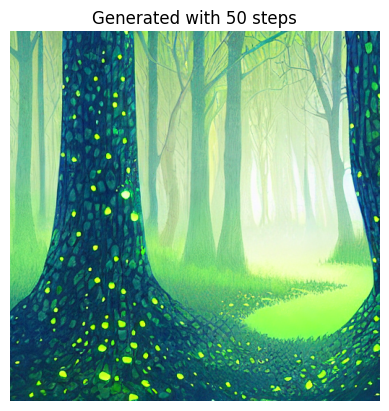

In [ ]:
prompt = "A mystical forest with glowing trees, digital art"
# Use default `num_inference_steps` by not including it as a parameter.

start = time.time()
image = pipe(prompt).images[0]
end = time.time()
print(f"Took {round(end-start,2)} seconds to generate with 50 steps.")

# Display
import matplotlib.pyplot as plt
plt.imshow(image)
plt.axis("off")
plt.title("Generated with 50 steps")
plt.show()

  0%|          | 0/10 [00:00<?, ?it/s]

Took 2.1 seconds to generate with 10 steps.


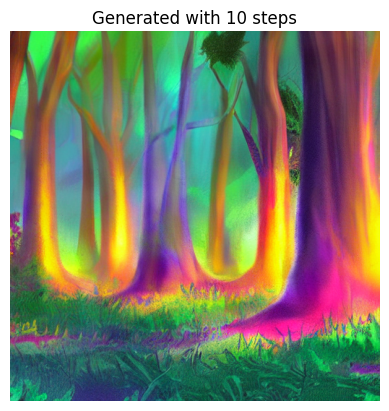

In [ ]:
# Set inference parameters
pipe.scheduler.config.num_inference_steps = 10  # Decrease number of denoising steps to 10

# Generate image using the same prompt as above
start = time.time()
image = pipe(prompt, num_inference_steps=pipe.scheduler.config.num_inference_steps).images[0]
end = time.time()
print(f"Took {round(end-start,2)} seconds to generate with 10 steps.")

# Display
import matplotlib.pyplot as plt
plt.imshow(image)
plt.axis("off")
plt.title("Generated with 10 steps")
plt.show()

  0%|          | 0/100 [00:00<?, ?it/s]

Took 16.2 seconds to generate with 100 steps.


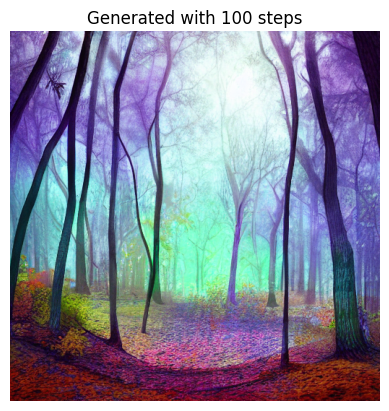

In [ ]:
# Set inference parameters
pipe.scheduler.config.num_inference_steps = 100  # Increase number of denoising steps to 100

# Generate image using the same prompt as above
start = time.time()
image = pipe(prompt, num_inference_steps=pipe.scheduler.config.num_inference_steps).images[0]
end = time.time()
print(f"Took {round(end-start,2)} seconds to generate with 100 steps.")

# Display
import matplotlib.pyplot as plt
plt.imshow(image)
plt.axis("off")
plt.title("Generated with 100 steps")
plt.show()

**Question 4** is about the code and prompts above.

